<a href="https://colab.research.google.com/github/luciestrada/Lab-Biose-ales-V4-6_Lucianas-/blob/main/pr%C3%A1ctica3_LucianaAcevedo_LucianaEstrada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Consulta de funciones:**
* #  Mean :

    Calcula el valor promedio de un conjunto de datos
* #  Var:

    Mide qué tan dispersos están los datos respecto a la media.
* #  Std:

    Es la raíz cuadrada de la varianza y también mide dispersión.



#PARTE 1 : Implementación de funciones Y Análisis estadístico de ECG

Saving signals.mat to signals (5).mat
dict_keys(['__header__', '__version__', '__globals__', 'Fs', 'ECG_asRecording', 'ECG_filtered', 'EMG_filtered1', 'EMG_filtered2', 'EMG_asRecording1', 'EMG_asRecording2'])
RMS: 4392.9682937490725
Duración de la señal: 30.0 segundos


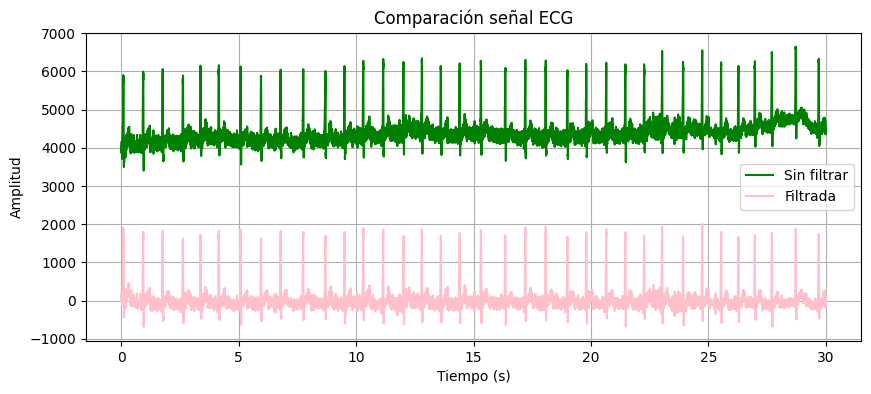

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
from scipy.io import loadmat # Import loadmat function

from google.colab import files
uploaded = files.upload()
datos = loadmat("signals.mat")

print(datos.keys())

senal = datos['ECG_asRecording'].squeeze()
senal_filtrada = datos['ECG_filtered'].squeeze()
fs = int(datos['Fs'][0][0])

def calcular_rms(x):
    return np.sqrt(np.mean(x**2)) #RMS

rms_val = calcular_rms(senal) #RMS de la señal
print("RMS:", rms_val)

#Tiempo de duración de la señal
t = np.arange(len(senal)) / fs
duracion = len(senal) / fs
print("Duración de la señal:", duracion, "segundos")

plt.figure(figsize=(10,4))

plt.plot(t, senal, color='green', label='Sin filtrar')
plt.plot(t, senal_filtrada, color='pink', label='Filtrada')

plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Comparación señal ECG")
plt.legend()
plt.grid()

plt.show()


Podemos observar como en la señal sin filtrar se distinguen claramente los picos QRS (los picos altos), y se evidencia su periodicidad. Sin embargo, esta señal tiene ruido, y está desplazada hacía arriba (~4000)(Componente DC de baja frecuencia --> OFFSET).

En comparación, la señal filtrada se encuentra centrada alrededor de cero y presenta una reducción significativa en su amplitud, lo que indica la eliminación de componentes no deseados como el ruido . Además, la señal filtrada permite resaltar mejor los cambios rápidos en la señal, lo cual es característico de señales ECG. Logrando identificar mejor la actividad cardiaca, y asegura que la información importante del ECG no fue eliminada despues del proceso de filtrado.

Las señales ECG contienen su información fisiológica relevante en un rango frecuencias aproximado entre 0.5 Hz y 40 Hz.  *Las cifras de referencia de los filtros a la hora de realizar un ECG:  0,5 Hz (filtro de paso alto) y 150 Hz (filtro de paso bajo). Si no son correctos pueden aparecer artefactos, asociados a movimientos cuando son frecuencias inferiores , o principalmente rudio relacioanda a las frecuencias superiores* [1]

Al realizar la comparación se logra identificar que el tipo de filtro es PASA AlTAS , ya que se elimina los componentes de muy baja frecuencia ,como el el desplazamiento de la señal( OFFSET),y permite el paso de las frecuencias asociadas a la señal ECG --> Conservando el rango de interés fisiológico del ECG.



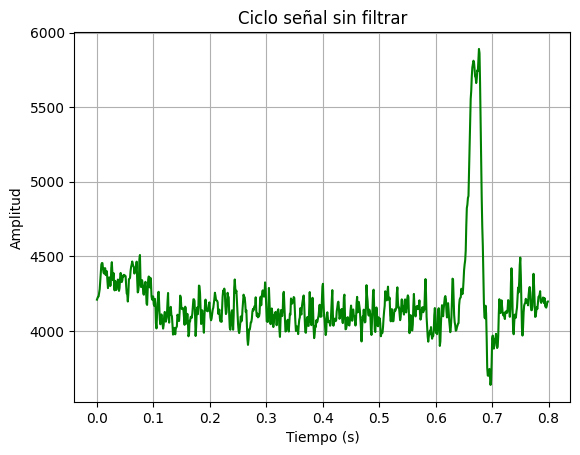

SEÑAL SIN FILTRAR
Media: 4196.9049392718825
Varianza: 80315.0175289181
Desv Std: 283.3990429216692
RMS: 4206.462419517574


In [ ]:
inicio = 2000
n = int(0.8 * fs)  # número de muestras en 0.8 s --> En un ciclo cardiaco

ciclo = senal[inicio:inicio + n]

t_ciclo = np.arange(n) / fs

import matplotlib.pyplot as plt

plt.figure()
plt.plot(t_ciclo, ciclo, color='green')
plt.title("Ciclo señal sin filtrar")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()
plt.show()


media = np.mean(ciclo)
varianza = np.var(ciclo)
desv = np.std(ciclo)
rms_val = calcular_rms(ciclo)

print("SEÑAL SIN FILTRAR")
print("Media:", media)
print("Varianza:", varianza)
print("Desv Std:", desv)
print("RMS:", rms_val)

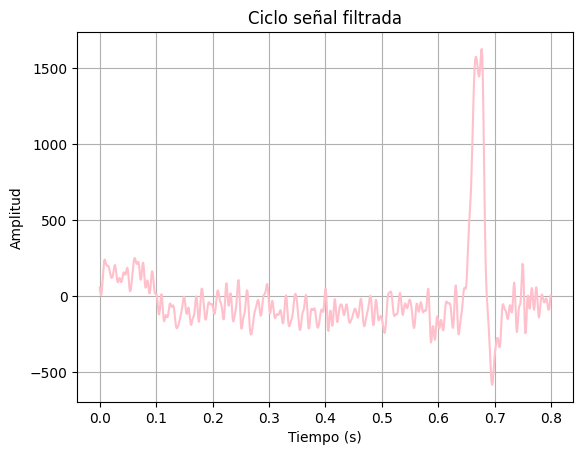


SEÑAL FILTRADA
Media: -20.2398459893594
Varianza: 77990.60549150783
Desv Std: 279.2679815007582
RMS: 280.00045867316146


In [ ]:
inicio = 2000
n = int(0.8 * fs)  # número de muestras en 0.8 s
ciclo_f = senal_filtrada[inicio:inicio + n]
t_ciclo_f = np.arange(n) / fs

# Graficar
plt.figure()
plt.plot(t_ciclo_f, ciclo_f, color='pink')
plt.title("Ciclo señal filtrada")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()
plt.show()


media_f = np.mean(ciclo_f)
varianza_f = np.var(ciclo_f)
desv_f = np.std(ciclo_f)
rms_f = calcular_rms(ciclo_f)

print("\nSEÑAL FILTRADA")
print("Media:", media_f)
print("Varianza:", varianza_f)
print("Desv Std:", desv_f)
print("RMS:", rms_f)

Antes de realizar el análisis de los resultados obtenidos , es importante mencionar que el clico cardiaco tiene una duración de alrededor de 0.8 s . **[2]**  


Comparando ambos resultados, podemos notar como hay diferencias importantes en los cálculos estadísticos.

Como se había observado previamente, la señal sin filtrar presenta una mayor amplitud y variabilidad, lo cual se refleja en un aumentando de la varianza,y la desviación estandar. Además, al identificar posibles tendencias en la señal, su media presenta un valor alejado del cero, lo que indica la presencia de una componente DC significativa (offset). Además, el valor RMS es muy cercano a la media, lo que confirma que la energía de la señal está dominada por este desplazamiento.

En contraste, la señal filtrada presenta una reducción significativa en la amplitud y la dispersión de datos, disminuyendo valores como la varianza, desviación estándar y la media, la cual tiende a estar más cerca del cero, indicando que el filtro eliminó la componente de baja frecuencia presente en la señal original.
De igual forma, el RMS disminuyó en la señal filtrada, demostrando la reducción de energía total en la señal, debido a la eliminación de componentes no deseados(Parte DC del desplazamiento). Mostrando únicamente la energía asociada a la señal fisiológica.

En el filtrado de señales EMG es un proceso fundamental debido a la alta susceptibilidad de estas señales al ruido e interferencias externas. Por esta razón, es necesario aplicar técnicas de filtrado que permitan eliminar los componentes no deseados, y convirtiendo la señal más limpia y estable **[3].**

Estos resultados indican que el filtro aplicado mejora la calidad de la señal sin afectar su información relevante.


/tmp/ipykernel_3001/2050157496.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)


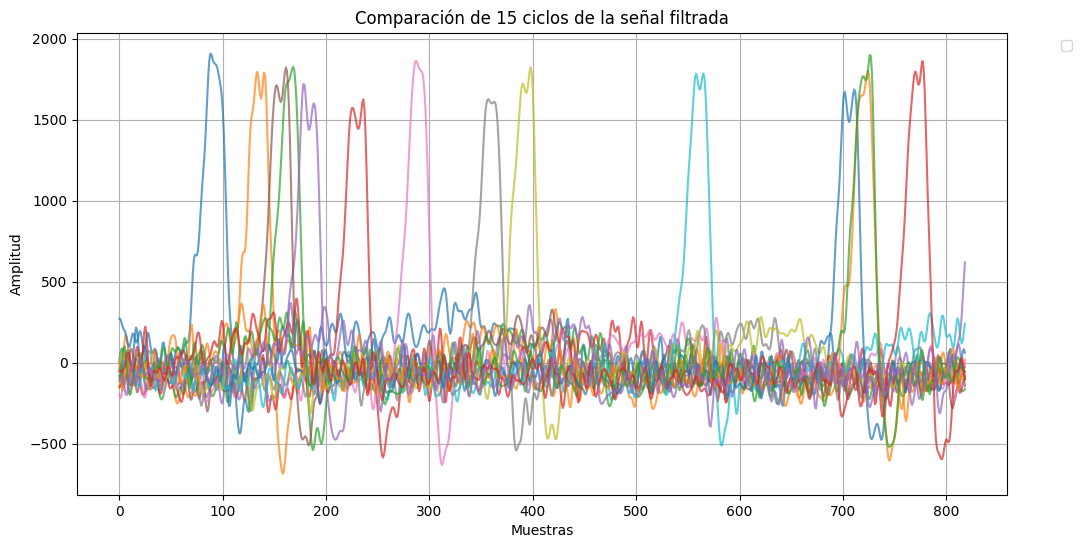

    Ciclo      Media      Varianza
0       1  92.613982  97104.796606
1       2  -5.759178  90783.766936
2       3  -5.569453  86514.425800
3       4  -9.398469  76845.820850
4       5  16.508281  77757.267582
5       6  -0.756074  88914.654952
6       7   9.959618  90163.126798
7       8   1.334138  74941.423090
8       9  12.906039  85844.720934
9      10  -3.598515  85788.141585
10     11 -10.872479  75328.282087
11     12  -6.044178  83294.080265
12     13  13.014388  91326.911390
13     14  -2.227201  94258.071794
14     15 -48.452460  14027.071224


In [ ]:
medias = []
varianzas = []
ciclos = []

tam = int(0.8 * fs) #Hay que separar el tamaño de cada ciclo( Según la literatura cada ciclo dura alrededor de 0.8s)

plt.figure(figsize=(12, 6))

for i in range(15):
    inicio = i * tam
    fin = inicio + tam

    segmento = senal_filtrada[inicio:fin]

    ciclos.append(segmento)
    medias.append(np.mean(segmento))
    varianzas.append(np.var(segmento))

    plt.plot(segmento, alpha=0.7)

plt.title("Comparación de 15 ciclos de la señal filtrada")
plt.xlabel("Muestras")
plt.ylabel("Amplitud")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
plt.grid(True)
plt.show()

# Crear el DataFrame correctamente
df_stats = pd.DataFrame({
    "Ciclo": np.arange(1, 16),
    "Media": medias,
    "Varianza": varianzas
})
print(df_stats)

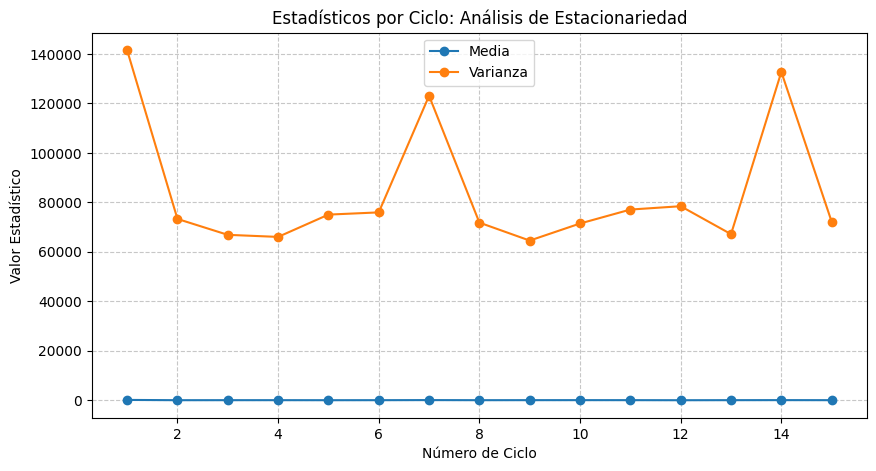

In [ ]:
df_stats.plot(x="Ciclo", y=["Media", "Varianza"], marker='o', figsize=(10,5))
plt.title("Estadísticos por Ciclo: Análisis de Estacionariedad")
plt.xlabel("Número de Ciclo")
plt.ylabel("Valor Estadístico")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Al graficar todo los ciclos en una sola figura, no es posible diferenciarlos claramente debido a la superposición de las señales. Por esta razón, se realizó un análisis basado en los cálculos estadísticos y en la gráfica de estos resultados.
En general al observar la gráfica de los diferentes ciclos de la señal filtrada, se evidencia que la mayoria presentan la misma forma y amplitud, pero hay cilcos donde hay valores atipicos y se alejan mucho del patrón.

En cuanto a la varianza, se evidencia que la mayoría de los ciclos presentan valores similares, lo que sugiere que la variabilidad de la señal se mantiene relativamente constante en el tiempo. Sin embargo valores como ~14027 (Ciclo 14) rompen el patrón,  lo cual puede deberse a variaciones fisiológicas, ruido o a la selección del segmento.

El análisis estadístico, se encontró que la media de los ciclos se mantiene cercana a cero, lo cual es consistente con el proceso de filtrado aplicado, ya que este elimina la componente de baja frecuencia y centra la señal, como se había mencionado antes. Sin embargo, hay unos ciclos que se alejan mucho de los esperado( 92,-48), estos valores son considerados como outliers, por lo que podemos decir que la señal no es perfectamente estable.

En el procesamiento de señales, la estacionariedad es una propiedad clave que facilita su análisis, ya que asume que características estadísticas como la media y la varianza permanecen constantes en el tiempo. Bajo esta condición, el comportamiento de la señal puede considerarse uniforme, permitiendo que el estudio de un segmento sea suficiente para describir sus propiedades generales. Sin embargo, en muchas señales reales, especialmente biomédicas, esta condición no se cumple estrictamente **[4]**.

En este caso, la media y la varianza se mantiene relativamente constantes,aunque presetan variaciones de lo que indica que **la señal no cumple completamente con la condición de estacionariedad.** --> Puede considerarse aproximadamente estacionaria.


In [ ]:
 from scipy.stats import shapiro
from scipy.stats import levene
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

c1 = ciclos[0]
c2 = ciclos[5]

stat1, p1 = shapiro(c1) #Normalidad
stat2, p2 = shapiro(c2)

print("Ciclo 1 p-value:", p1)
print("Ciclo 2 p-value:", p2)

stat, p_levene = levene(c1, c2) #homocedasticidad
print("Levene p-value:", p_levene)

stat, p_t = ttest_ind(c1, c2)  #Prueba t
print("t-test p-value:", p_t)

#No cumple los requisitos, se realiza un análisis no paramétrico
stat, p_mw = mannwhitneyu(c1, c2) #MANN-WHITNEY
print("Mann-Whitney p-value:", p_mw)

Ciclo 1 p-value: 4.0830803216122737e-41
Ciclo 2 p-value: 1.5818990106472823e-45
Levene p-value: 1.7750819887311372e-08
t-test p-value: 2.1635770296592833e-12
Mann-Whitney p-value: 4.308209983316779e-24


Se seleccionaron dos ciclos de la señal filtrada y se evaluaron los supuestos necesarios para la aplicación de la prueba t.

La prueba de normalidad de Shapiro-Wilk dió como resultado valores p de 8.89×10⁻¹⁵ y 2.52×10⁻¹⁰ para cada ciclo respectivamente, ambos menores a 0.05, lo que indica que los datos no siguen una distribución normal.

De igual forma la prueba de Levene presentó un valor p de 5.37×10⁻¹⁴⁹, lo que indica que las varianzas entre los ciclos son significativamente diferentes.

Debido a que las dos pruebas anteriores no se cumplen, la prueba t no se considera válida para este análisis. Aunque esta arrojó un valor p de 0.68, indicando que no existen diferencias estadísticamente significativas entre los ciclos, este resultado no puede considerarse confiable bajo estas condiciones.

Debido a estos resultados se aplicó la prueba no paramétrica U de Mann-Whitney, la cual arrojó valor p de 0.149, mayor a 0.05, lo que indica que no existen diferencias estadísticamente significativas entre los ciclos analizados.

Estos resultados sugieren que desde el punto de vista estadístico, ambos ciclos presentan distribución similar, sin embargo, esto no implica que sea una señal estacionaria, ya que la estacionariedad implica que las propiedades estadísticas se mantengan constantes a lo largo de toda la señal.



In [ ]:
from statsmodels.tsa.stattools import adfuller

resultado = adfuller(senal_filtrada)

print("ADF Statistic:", resultado[0])
print("p-value:", resultado[1])

ADF Statistic: -57.61899439864359
p-value: 0.0


Finalmente se aplicó la prueba de Dickey-Fuller aumentada(Evalua toda la señal --> tendecia global), obteniendo un estadístico de -57.62 y un valor p de 0.0, lo que indica que se rechaza la hipótesis nula de no estacionariedad.

Por lo tanto, se concluye que la señal es estacionaria desde un punto de vista global. No obstante,  se observaron variaciones entre ciclos individuales(Otras pruebas , estas comparan segmentos en especifico ), lo cual es consistente con el comportamiento de las bioseñales, que no son estrictamente estacionarias sino **aproximadamente estacionarias**.


# PARTE 2: Comparación estadística de Energía de señales EEG



In [ ]:
#Comparación estadística de Energía de señales EEG
from google.colab import drive
import os

drive.mount('/content/drive')


print(os.listdir('/content/drive/MyDrive/datos_senales_datos_parkinson_cursos'))


ruta_control = "/content/drive/MyDrive/datos_senales_datos_parkinson_cursos/control"
ruta_parkinson = "/content/drive/MyDrive/datos_senales_datos_parkinson_cursos/parkinson"

print(os.listdir(ruta_control))
print(os.listdir(ruta_parkinson))

control = []

for archivo in os.listdir(ruta_control):
    data = loadmat(os.path.join(ruta_control, archivo))
    control.append(data)

print(control[0].keys())

print(control[0]['data'].shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['parkinson', 'control']
['C001R_EP_reposo.mat', 'C002_EP_reposo.mat', 'C004_EP_reposo.mat', 'C010_EP_reposo.mat', 'C006_EP_reposo.mat', 'C012_EP_reposo.mat', 'C007_EP_reposo.mat', 'C005_EP_reposo_Repetido.mat', 'C011_EP_reposo.mat', 'C019_EP_reposo.mat', 'C018_EP_reposo.mat', 'C015_EP_reposo.mat', 'C021_EP_reposo.mat', 'C013_EP_reposo.mat', 'C020_EP_reposo.mat', 'C027_EP_reposo.mat', 'C028_EP_reposo.mat', 'C024_EP_reposo.mat', 'C025_EP_reposo.mat', 'C026_EP_reposo.mat', 'C023_EP_reposo.mat', 'C029_EP_reposo.mat', 'C031_EP_reposo.mat', 'C034_EP_reposo.mat', 'C032_EP_reposo.mat', 'C030_EP_reposo.mat', 'C033R_EP_reposo.mat', 'C036_EP_reposo.mat', 'C044_EP_reposo.mat', 'C042_EP_reposo.mat', 'C037_EP_reposo.mat', 'C041_EP_reposo.mat', 'C040_EP_reposo.mat', 'C045_EP_reposo.mat', 'C046_EP_reposo.mat', 'C049_EP_reposo.mat']
['P007_EP_reposo.mat', 'P004_EP_reposo.mat

8 → canales

2000 → muestras por época

180 → épocas

In [ ]:
# 1. Función de energía promedio por canal
def calcular_energia_promedio(matriz_eeg):
    # Calculamos energía (muestras al cuadrado)
    energia = np.square(matriz_eeg) #La fórmula de energia es al cuadrado x(i)^2
    # Sumamos en el eje de las muestras (eje 1)
    energia_por_epoca = np.sum(energia, axis=1)
    # Promediamos entre todas las épocas (eje 1 de la nueva matriz)
    energia_promedio_canales = np.mean(energia_por_epoca, axis=1)
    return energia_promedio_canales

# 2. Procesamiento de Grupos
canales = [f'Canal_{i+1}' for i in range(8)]

def crear_df_grupo(ruta, nombre_grupo):
    lista_energias = []
    sujetos = []

    for archivo in os.listdir(ruta):
        if archivo.endswith(".mat"):
            res = loadmat(os.path.join(ruta, archivo))
            data_eeg = res['data']

            # Calcular energía para este sujeto
            e_promedio = calcular_energia_promedio(data_eeg)
            lista_energias.append(e_promedio)

            sujetos.append(archivo.replace('.mat', ''))

    df = pd.DataFrame(lista_energias, columns=canales, index=sujetos)
    df.index.name = '#sujeto'
    return df


df_control = crear_df_grupo(ruta_control, "Control")
df_parkinson = crear_df_grupo(ruta_parkinson, "Parkinson")

print("--- DataFrame Control ---")
print(df_control.head())
print("\n--- DataFrame Parkinson ---")
print(df_parkinson.head())

--- DataFrame Control ---
                      Canal_1       Canal_2       Canal_3       Canal_4  \
#sujeto                                                                   
C001R_EP_reposo  21465.650358  20985.907912  22760.149588  18505.640284   
C002_EP_reposo   15966.402868  17617.810248  20804.937129  19654.400017   
C004_EP_reposo   14148.673322  18283.999666  28749.932148  14270.726911   
C010_EP_reposo   11197.554574  10948.368805  12737.004665  10745.161921   
C006_EP_reposo   18510.829979  19738.489375  20911.792748  21828.254399   

                      Canal_5       Canal_6       Canal_7       Canal_8  
#sujeto                                                                  
C001R_EP_reposo  29730.163026  25244.158073  22781.327587  24658.599512  
C002_EP_reposo   16678.982063  93894.049009  66862.496275  75685.125872  
C004_EP_reposo   28787.445978  14661.417740  15940.154095  19499.898656  
C010_EP_reposo   10329.642418  21461.605831  15493.212776  27414.375247  
C006

In [ ]:
resultados = []

for col in canales:
    g1 = df_control[col]
    g2 = df_parkinson[col]

    # Supuestos
    _, p_norm1 = stats.shapiro(g1)
    _, p_norm2 = stats.shapiro(g2)
    _, p_lev = stats.levene(g1, g2)

    # Decisión de prueba
    if p_norm1 > 0.05 and p_norm2 > 0.05:
        stat, p_val = stats.ttest_ind(g1, g2, equal_var=(p_lev > 0.05))
        prueba = "T-Student"
    else:
        stat, p_val = stats.mannwhitneyu(g1, g2)
        prueba = "Mann-Whitney"

    resultados.append({
        'Canal': col,
        'Prueba': prueba,
        'p-value': p_val,
        'Diferencia_Significativa': "SÍ" if p_val < 0.05 else "NO"
    })

df_final = pd.DataFrame(resultados)
print("\n--- RESULTADOS COMPARATIVOS ---")
print(df_final)


--- RESULTADOS COMPARATIVOS ---
     Canal        Prueba   p-value Diferencia_Significativa
0  Canal_1  Mann-Whitney  0.405701                       NO
1  Canal_2  Mann-Whitney  0.570528                       NO
2  Canal_3  Mann-Whitney  0.460373                       NO
3  Canal_4  Mann-Whitney  0.234462                       NO
4  Canal_5  Mann-Whitney  0.560018                       NO
5  Canal_6  Mann-Whitney  0.280075                       NO
6  Canal_7  Mann-Whitney  0.118301                       NO
7  Canal_8  Mann-Whitney  0.150544                       NO


En las pruebas estadisiticas se hizo la prueba MANN-WHITNEY, porque al menos uno de las condiciones de la prueba T no se cumplió.

Al observar los resultados de los canales observamos que en el Grupo de control tiene los valores de los canales moderados,en cambio se ve una mayor dispersión dentro del grupo Parkinson, los sujetos tienen canales con energías muy altas. Hay sujetos dentro del mismo grupo con energías muy dispares. Por ejemplo en Parkinson, P005 tiene Canal_6 = 251,649 mientras P001 tiene 22,798. Esa variabilidad opaca las diferencias reales entre grupos.


Ningún canal mostró una diferencia significativa, no se puede afirmar por los valores estadisiticos que la energía promedio del EEG en reposo diferencie a pacientes con Parkinson de controles sanos. Este resultado puede deberse a que los valores de energía de ambos grupos son muy similares entre sí, y a que el número de sujetos no es suficiente para detectar diferencias.

Además, desde la literatura se sabe que las diferencias en señales EEG asociadas a la enfermedad de Parkinson suelen ser más evidentes cuando se analizan bandas de frecuencia específicas, en lugar de la energía total de la señal **[5]**.

En conclusión, con este análisis no se puede afirmar que la energía del EEG sea suficiente para diferenciar entre sujetos sanos y pacientes con Parkinson.

**Conclusiones**

• Al evaluar los ciclos cardiacos, algunas pruebas indicaron que la señal no es estacionaria, ya que estes tipo de pruebas se centran es en analizar segmentos pequeños donde se pueden presentar picos anormales. Sin embargo, la prueba de Dickey-Fuller,  evalúa el comportamiento global, y esta indicó que la señal es estacionaria lo que se puede interpretar que la mayoría de la señal si sigue un patrón, es decir, que mantiene relativamente caracterieiticas ( amplitud) en el tiempo. Las pequeñas variaciones confirman que es una señal estocástica, es decir, que tiene un componente aleatorio y no se comporta de forma completamente predecible.  

• En la segunda parte se comparó la energía del EEG entre sujetos sanos y pacientes con Parkinson. Aunque son visibles algunas diferencias, las pruebas estadísticas no arrojaron resultados de diferencias significativos en ningún canal. Esto se debe principalmente a que la energía global no captura los detalles en la frecuencia donde realmente se diferencian estos grupos, como la banda beta (13-30 Hz)**[5]**. Para este tipo de análisis es fundamental elegir estudios con más descriptores espectrales(Potencia por banda de frecuencia,frecuencia por pico) que la energía total, para evitar que estos resultados no sean sólidos.

• El cálculo de parámetros como la media, varianza y desviación estándar fue fundamental para establecer la estabilidad de las señales, mientras que el uso del RMS permitió cuantificar la energía total de las ondas cerebrales y cardíacas, facilitando la detección de cambios en el estado fisiológico que no son evidentes a simple vista. Se concluye que el filtrado digital es un proceso indispensable en el EEG para eliminar artefactos sin alterar las frecuencias de interés (alfa, beta, theta, etc.). En última instancia, la integración de estos métodos estadísticos en Python demuestra ser una metodología robusta para la extracción de biomarcadores, permitiendo pasar de una inspección visual subjetiva a un diagnóstico basado en datos cuantitativos precisos.





## **REFERENCIAS**

1. ¿Sabes para qué sirven los filtros y cuáles son los valores recomendados? (2023, julio 5). CardioTeca. https://www.cardioteca.com/pildoras-ecg/5017-sabes-para-que-sirven-los-filtros-y-cuales-son-los-valores-recomendados.html

2. Ciclo Cardíaco: Entendiendo las fases del ciclo cardiaco. (2024, agosto 16). Fisioterapia sol y luz. https://fisioterapiasolyluz.es/ciclo-cardiaco-entendiendo-las-fases-del-ciclo-cardiaco/?expand_article=1



3. Sul, J., Piyathilaka, L., Moratuwage, D., Arachchige, S. D., Jayawardena, A., Kahandawa, G., & Preethichandra, D. M. G. (2025). Electromyography Signal Acquisition, Filtering, and Data Analysis for Exoskeleton Development. Sensors, 25(13), 4004. https://doi.org/10.3390/s25134004

4. ScienceDirect. (s.f.). Stationarity. ScienceDirect Topics. Recuperado el 25 de marzo de 2026, de https://www.sciencedirect.com/topics/engineering/stationarity

5. Stoffers, D., Bosboom, J. L. W., Deijen, J. B., Wolters, E. C., Berendse, H. W., & Stam, C. J. (2007). Slowing of oscillatory brain activity is a stable characteristic of Parkinson’s disease without dementia. Brain: A Journal of Neurology, 130(Pt 7), 1847–1860. https://doi.org/10.1093/brain/awm034